<a href="https://colab.research.google.com/github/tamaki-gth/cartpole_project/blob/main/cartpole.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

m1=1
m2=1
l=0.5
g=9.8
J=0.5
F=0
tau=0.01

def f(z,m1,m2,l,J,F,g):

    x,x_dot,theta,theta_dot=z

    A1=np.array([[m1+m2,m2*l*np.cos(theta)],[m2*l*np.cos(theta),m2*l**2+J]])
    A2=np.array([[m2*l*theta_dot**2*np.sin(theta)+F],[m2*g*l*np.sin(theta)]])
    A1_inv=np.linalg.inv(A1)

    h=A1_inv@A2

    #return np.array([h[0,0],h[1,0],x_dot,theta_dot])
    return np.array([x_dot, h[0,0], theta_dot, h[1,0]])

def RungeKutta(z,tau,m1,m2,l,J,F,g):
    k1=f(z,m1,m2,l,J,F,g)
    k2=f(z+k1*tau/2,m1,m2,l,J,F,g)
    k3=f(z+k2*tau/2,m1,m2,l,J,F,g)
    k4=f(z+k3*tau,m1,m2,l,J,F,g)
    return z+tau/6*(k1+2*k2+2*k3+k4)


In [50]:
class CartPoleEnv:
    def __init__(self):
        self.reset()

    def reset(self):
        self.z = np.array([0.0, 0.0, 0.05, 0.0])
        return self.z

    def step(self, action):
        F = float(action)

        self.z = RungeKutta(self.z, tau, m1, m2, l, J, F, g)

        x, x_dot, theta, theta_dot = self.z

        r_theta = 10 * theta**2
        r_theta_dot =  theta_dot**2
        r_x_dot = 0.1 * x_dot**2
        r_alive = 1.0

        reward1 = r_alive - r_theta - r_theta_dot - r_x_dot

        #reward = -(theta**2 + 0.1*theta_dot**2 + 0.01*x**2 + 0.001*F**2)
        #reward = -(theta**2 + 0.1*theta_dot**2)
        #reward = 1.0 -(10*theta**2 + theta_dot**2+0.1*x_dot**2)
        reward = 1.0
        done = abs(theta) > 0.2
        #if done:
          #reward-=10

        info={"r_theta": r_theta,"r_theta_dot": r_theta_dot,"r_x_dot": r_x_dot,"r_alive": r_alive}

        return self.z, reward, done,info,reward1

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

class ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()

        self.actor = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh()
        )

        self.mu = nn.Linear(64, 1)
        self.log_std = nn.Parameter(torch.zeros(1))

        self.critic = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, state):
        x = self.actor(state)
        mu = self.mu(x)
        std = torch.exp(self.log_std)
        dist = Normal(mu, std)
        value = self.critic(state)
        return dist, value

In [4]:
class PPO:
    def __init__(self):
        self.model = ActorCritic()
        self.optimizer = optim.Adam(self.model.parameters(), lr=3e-4)

        self.gamma = 0.99
        self.eps_clip = 0.2

    def select_action(self, state):
        state = torch.FloatTensor(state[1:])
        dist, value = self.model(state)

        action = dist.sample()
        log_prob = dist.log_prob(action)

        return action.detach().numpy(), log_prob.detach(), value.detach()

    def update(self, memory):
        states = torch.FloatTensor([s[1:] for s in memory['states']])
        actions = torch.FloatTensor(memory['actions'])
        old_log_probs = torch.stack(memory['log_probs']).detach()
        returns = torch.FloatTensor(memory['returns'])

        for _ in range(10):
            dist, values = self.model(states)
            log_probs = dist.log_prob(actions)

            ratio = torch.exp(log_probs - old_log_probs)

            advantages = returns - values.detach().squeeze()

            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1-self.eps_clip, 1+self.eps_clip) * advantages

            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = (returns - values.squeeze()).pow(2).mean()

            loss = actor_loss + 0.5 * critic_loss

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

In [37]:
from IPython.display import HTML
import matplotlib.pyplot as plt
from matplotlib import animation
from google.colab import drive
drive.mount('/content/drive')

def save_animation(z_array,l,actions, filename="cartpole.mp4"):
    x = z_array[:,0]
    x_dot=z_array[:,1]
    theta = z_array[:,2]
    theta_dot=z_array[:,3]

    xc = x + l*np.sin(theta)
    yc = l*np.cos(theta)

    fig, ax = plt.subplots()

    def update(i):
        ax.clear()
        ax.set_xlim(np.min(x)-1, np.max(x)+1)
        ax.set_ylim(-l, l)
        ax.set_aspect('equal')

        ax.plot([x[i]], [0], "bo")
        ax.plot([xc[i]], [yc[i]], "ro")

    ani = animation.FuncAnimation(fig, update, frames=len(z_array))
    filename = "/content/drive/MyDrive/lab_activity/cartpole.mp4"
    writer = animation.FFMpegWriter(fps=100)
    ani.save(filename, writer=writer)
    #ani.save(filename, writer="ffmpeg", fps=100)
    print("len(z_array) ",len(z_array))


    plt.close()
    #display(save_animation(states_record, l, filename))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1224/128792324.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F = float(action)


Episode 0 | Reward 49.00 | Step 48
Episode 1 | Reward 43.00 | Step 42
Episode 2 | Reward 92.00 | Step 91
Episode 3 | Reward 51.00 | Step 50
Episode 4 | Reward 56.00 | Step 55
Episode 5 | Reward 52.00 | Step 51
Episode 6 | Reward 42.00 | Step 41
Episode 7 | Reward 47.00 | Step 46
Episode 8 | Reward 33.00 | Step 32
Episode 9 | Reward 33.00 | Step 32
Episode 10 | Reward 47.00 | Step 46
Episode 11 | Reward 33.00 | Step 32
Episode 12 | Reward 42.00 | Step 41
Episode 13 | Reward 32.00 | Step 31
Episode 14 | Reward 26.00 | Step 25
Episode 15 | Reward 32.00 | Step 31
Episode 16 | Reward 29.00 | Step 28
Episode 17 | Reward 33.00 | Step 32
Episode 18 | Reward 32.00 | Step 31
Episode 19 | Reward 36.00 | Step 35
Episode 20 | Reward 33.00 | Step 32
Episode 21 | Reward 37.00 | Step 36
Episode 22 | Reward 34.00 | Step 33
Episode 23 | Reward 38.00 | Step 37
Episode 24 | Reward 39.00 | Step 38
Episode 25 | Reward 35.00 | Step 34
Episode 26 | Reward 41.00 | Step 40
Episode 27 | Reward 38.00 | Step 37
Ep

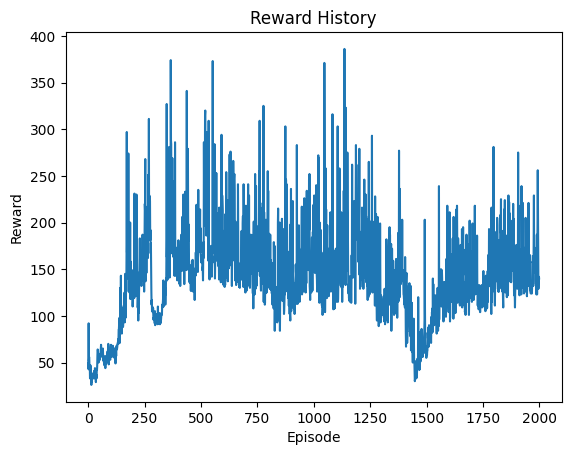

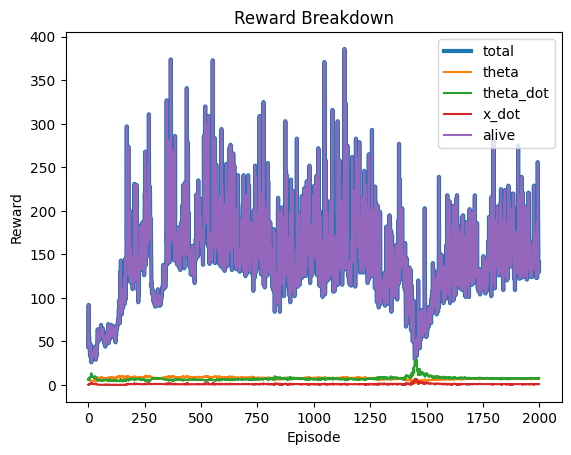

In [51]:
import numpy as np

def train():
    env = CartPoleEnv()
    agent = PPO()
    best_reward = -float("inf")
    best_episode = 0

    rewards_history=[]
    r_theta_list = []
    r_theta_dot_list = []
    r_x_dot_list = []
    r_alive_list = []

    max_episodes = 2000
    max_steps = 1000

    max_timesteps = max_episodes * max_steps
    timesteps_so_far = 0

    for episode in range(max_episodes):
        state = env.reset()

        sum_r_theta = 0
        sum_r_theta_dot = 0
        sum_r_x_dot = 0
        sum_r_alive = 0

        record = (episode == max_episodes - 1)

        if record:
            states_record = []
            actions_record = []

        memory = {'states':[], 'actions':[], 'log_probs':[],
                  'rewards':[], 'dones':[]}

        total_reward = 0

        for t in range(max_steps):
            action, log_prob, _ = agent.select_action(state)

            action_env = action * 10.0

            next_state, reward, done, info,reward1 = env.step(action_env)

            sum_r_theta += info["r_theta"]
            sum_r_theta_dot += info["r_theta_dot"]
            sum_r_x_dot += info["r_x_dot"]
            sum_r_alive += info["r_alive"]

            if record:
                states_record.append(state.copy())
                actions_record.append(action_env[0])

            memory['states'].append(state)
            memory['actions'].append(action)
            memory['log_probs'].append(log_prob)
            memory['rewards'].append(reward)
            memory['dones'].append(done)

            state = next_state
            total_reward += reward
            timesteps_so_far += 1

            if done:
                break

        returns = []
        G = 0
        for r, d in zip(reversed(memory['rewards']), reversed(memory['dones'])):
            if d:
                G = 0
            G = r + agent.gamma * G
            returns.insert(0, G)

        memory['returns'] = returns

        cur_lrmult = max(1.0 - float(timesteps_so_far) / (max_timesteps/2), 0)
        if cur_lrmult < 1e-5:
            cur_lrmult = 1e-5

        for param_group in agent.optimizer.param_groups:
            param_group['lr'] = 3e-4 * cur_lrmult

        agent.update(memory)

        if total_reward > best_reward:
          best_reward = total_reward
          torch.save(agent.model.state_dict(),"/content/drive/MyDrive/lab_activity/weights/best.pth")
          best_episode = episode

        if episode % 100 == 0:
          torch.save(agent.model.state_dict(),f"/content/drive/MyDrive/lab_activity/weights/ep{episode}.pth")

        #torch.save(agent.model.state_dict(), f"/content/drive/MyDrive/lab_activity/weights/ep{episode}.pth")

        print(f"Episode {episode} | Reward {total_reward:.2f} | Step {t}")

        rewards_history.append(total_reward)
        r_theta_list.append(sum_r_theta)
        r_theta_dot_list.append(sum_r_theta_dot)
        r_x_dot_list.append(sum_r_x_dot)
        r_alive_list.append(sum_r_alive)

        if record:
            #save_animation(np.array(states_record), l, np.array(actions_record))
            print(f"Best episode  {best_episode}")

            plt.figure()
            plt.plot(rewards_history)
            plt.xlabel("Episode")
            plt.ylabel("Reward")
            plt.title("Reward History")
            plt.show()

            plt.figure()
            plt.plot(rewards_history, label="total", linewidth=3)

            plt.plot(r_theta_list, label="theta")
            plt.plot(r_theta_dot_list, label="theta_dot")
            plt.plot(r_x_dot_list, label="x_dot")
            plt.plot(r_alive_list, label="alive")
            plt.legend()
            plt.xlabel("Episode")
            plt.ylabel("Reward")
            plt.title("Reward Breakdown")
            plt.show()



train()

In [52]:
def play_best():
    env = CartPoleEnv()

    model = ActorCritic()
    model.load_state_dict(torch.load("/content/drive/MyDrive/lab_activity/weights/best.pth"))
    model.eval()

    state = env.reset()
    states_record = []
    actions_record = []

    for _ in range(1000):
        state_tensor = torch.FloatTensor(state[1:])
        dist, _ = model(state_tensor)

        # ←超重要：ランダムじゃなくする
        action = dist.mean.detach().numpy()

        action_env = action * 10.0

        states_record.append(state.copy())
        actions_record.append(action_env[0])

        state, _, done, _, _ = env.step(action_env)


        if done:
            break

    save_animation(np.array(states_record), l, np.array(actions_record))

play_best()

/tmp/ipykernel_1224/128792324.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F = float(action)


len(z_array)  191


In [48]:
def play():
    env = CartPoleEnv()
    any_episode=1000

    model = ActorCritic()
    model.load_state_dict(torch.load(f"/content/drive/MyDrive/lab_activity/weights/ep{any_episode}.pth"))
    model.eval()

    state = env.reset()
    states_record = []
    actions_record = []

    for _ in range(1000):
        state_tensor = torch.FloatTensor(state[1:])
        dist, _ = model(state_tensor)

        # ←超重要：ランダムじゃなくする
        action = dist.mean.detach().numpy()

        action_env = action * 10.0

        states_record.append(state.copy())
        actions_record.append(action_env[0])

        state, _, done, _, _ = env.step(action_env)


        if done:
            break

    save_animation(np.array(states_record), l, np.array(actions_record))

play()

/tmp/ipykernel_1224/3422634398.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F = float(action)


len(z_array)  166
